# DATA 604 – Week 3 Assignment
## Queue Modeling and Simulation
### Laboratory Sample Processing Queue

**Student:** Barakat Adigun  
**Course:** DATA 604 – Modeling and Simulation  
**Date:** September 17th, 2026

In [81]:
!pip install simpy

In [82]:
import simpy
import random
import statistics
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Narrative of the Process and Attributes Considered

This simulation models a routine laboratory sample-processing system. Samples arrive at the laboratory and move through four main stages: registration, preparation, testing, and result review.

Each sample represents an entity in the simulation. The resources are the laboratory staff and equipment required to process the samples.

The estimated processing times and capacities are:

| Process Step | Processing Time | Resource Capacity |
|---|---:|---:|
| Registration | 3 minutes | 1 staff member |
| Sample Preparation | 8 minutes | 1 technician |
| Testing/Analysis | 15 minutes | 1 analyzer |
| Result Review | 5 minutes | 1 scientist |

Samples arrive approximately every 5 to 10 minutes. Because resources have limited capacity, a sample may have to wait in a queue when another sample is already being processed.

In [83]:
# Simulation settings

RANDOM_SEED = 42
SIMULATION_TIME = 480   # 8-hour workday in minutes

REGISTRATION_TIME = 3
PREPARATION_TIME = 8
TESTING_TIME = 15
REVIEW_TIME = 5

MIN_ARRIVAL_TIME = 5
MAX_ARRIVAL_TIME = 10

random.seed(RANDOM_SEED)

print("Simulation settings created.")

Simulation settings created.


In [84]:
# ORIGINAL PROCESS SIMULATION

# Lists to store waiting times
registration_waits = []
preparation_waits = []
testing_waits = []
review_waits = []
total_times = []

def process_sample(env, sample_id, registration, preparation, analyzer, reviewer):
    arrival_time = env.now

    # Registration
    start_wait = env.now
    with registration.request() as request:
        yield request
        registration_waits.append(env.now - start_wait)
        yield env.timeout(REGISTRATION_TIME)

    # Sample Preparation
    start_wait = env.now
    with preparation.request() as request:
        yield request
        preparation_waits.append(env.now - start_wait)
        yield env.timeout(PREPARATION_TIME)

    # Testing / Analysis
    start_wait = env.now
    with analyzer.request() as request:
        yield request
        testing_waits.append(env.now - start_wait)
        yield env.timeout(TESTING_TIME)

    # Result Review
    start_wait = env.now
    with reviewer.request() as request:
        yield request
        review_waits.append(env.now - start_wait)
        yield env.timeout(REVIEW_TIME)

    total_times.append(env.now - arrival_time)


def sample_generator(env, registration, preparation, analyzer, reviewer):
    sample_id = 0

    while True:
        sample_id += 1

        env.process(
            process_sample(
                env,
                sample_id,
                registration,
                preparation,
                analyzer,
                reviewer
            )
        )

        arrival_interval = random.uniform(
            MIN_ARRIVAL_TIME,
            MAX_ARRIVAL_TIME
        )

        yield env.timeout(arrival_interval)

In [85]:
# Run the original simulation

random.seed(RANDOM_SEED)

env = simpy.Environment()

registration = simpy.Resource(env, capacity=1)
preparation = simpy.Resource(env, capacity=1)
analyzer = simpy.Resource(env, capacity=1)
reviewer = simpy.Resource(env, capacity=1)

env.process(
    sample_generator(
        env,
        registration,
        preparation,
        analyzer,
        reviewer
    )
)

env.run(until=SIMULATION_TIME)

print("Original process simulation completed.")
print("Samples completed:", len(total_times))

Original process simulation completed.
Samples completed: 30


In [86]:
# Calculate original process results

original_results = {
    "Registration": statistics.mean(registration_waits),
    "Preparation": statistics.mean(preparation_waits),
    "Testing": statistics.mean(testing_waits),
    "Review": statistics.mean(review_waits)
}

print("AVERAGE WAITING TIME BY PROCESS")
print("--------------------------------")

for process, wait in original_results.items():
    print(f"{process}: {wait:.2f} minutes")

print("\nAverage Total Time in System:",
      round(statistics.mean(total_times), 2),
      "minutes")

AVERAGE WAITING TIME BY PROCESS
--------------------------------
Registration: 0.00 minutes
Preparation: 22.98 minutes
Testing: 108.31 minutes
Review: 0.00 minutes

Average Total Time in System: 146.7 minutes


## 2. Analysis of Bottlenecks in the Queue

The results of the original simulation show that the Testing/Analysis stage is the primary bottleneck in the laboratory process. Samples waited an average of 108.31 minutes before testing. In comparison, the average waiting time for sample preparation was 22.98 minutes, while registration and result review had no average waiting time.

The testing stage requires 15 minutes per sample and has only one analyzer available. Because samples arrive every 5 to 10 minutes, they arrive faster than a single analyzer can process them. This causes samples to accumulate in the testing queue.

The original simulation completed 30 samples during the simulated eight-hour workday, and completed samples spent an average of 146.70 minutes in the system. These results suggest that increasing the capacity of the testing stage may reduce the queue and improve the overall process.

## 3. Suggested Changes

To improve the process, the capacity of the Testing/Analysis stage will be increased from one analyzer to two analyzers. The processing time will remain 15 minutes per sample.

Adding a second analyzer allows two samples to be tested simultaneously. This change is expected to reduce the waiting time at the testing stage and decrease the overall time that samples spend in the system.

All other resource capacities and processing times will remain unchanged so that the effect of increasing testing capacity can be compared with the original process.

In [87]:
# MODIFIED PROCESS SIMULATION
# Improvement: Increase analyzer capacity from 1 to 2

modified_registration_waits = []
modified_preparation_waits = []
modified_testing_waits = []
modified_review_waits = []
modified_total_times = []

def modified_process_sample(env, sample_id, registration,
                            preparation, analyzer, reviewer):

    arrival_time = env.now

    # Registration
    start_wait = env.now
    with registration.request() as request:
        yield request
        modified_registration_waits.append(env.now - start_wait)
        yield env.timeout(REGISTRATION_TIME)

    # Sample Preparation
    start_wait = env.now
    with preparation.request() as request:
        yield request
        modified_preparation_waits.append(env.now - start_wait)
        yield env.timeout(PREPARATION_TIME)

    # Testing / Analysis
    start_wait = env.now
    with analyzer.request() as request:
        yield request
        modified_testing_waits.append(env.now - start_wait)
        yield env.timeout(TESTING_TIME)

    # Result Review
    start_wait = env.now
    with reviewer.request() as request:
        yield request
        modified_review_waits.append(env.now - start_wait)
        yield env.timeout(REVIEW_TIME)

    modified_total_times.append(env.now - arrival_time)


def modified_sample_generator(env, registration, preparation,
                              analyzer, reviewer):

    sample_id = 0

    while True:
        sample_id += 1

        env.process(
            modified_process_sample(
                env,
                sample_id,
                registration,
                preparation,
                analyzer,
                reviewer
            )
        )

        arrival_interval = random.uniform(
            MIN_ARRIVAL_TIME,
            MAX_ARRIVAL_TIME
        )

        yield env.timeout(arrival_interval)

In [88]:
# Run modified simulation

random.seed(RANDOM_SEED)

env2 = simpy.Environment()

registration2 = simpy.Resource(env2, capacity=1)
preparation2 = simpy.Resource(env2, capacity=1)

# MODIFICATION: Two analyzers instead of one
analyzer2 = simpy.Resource(env2, capacity=2)

reviewer2 = simpy.Resource(env2, capacity=1)

env2.process(
    modified_sample_generator(
        env2,
        registration2,
        preparation2,
        analyzer2,
        reviewer2
    )
)

env2.run(until=SIMULATION_TIME)

print("Modified process simulation completed.")
print("Samples completed:", len(modified_total_times))

Modified process simulation completed.
Samples completed: 57


##### Calculate modified process results

modified_results = {
    "Registration": statistics.mean(modified_registration_waits),
    "Preparation": statistics.mean(modified_preparation_waits),
    "Testing": statistics.mean(modified_testing_waits),
    "Review": statistics.mean(modified_review_waits)
}

print("MODIFIED PROCESS - AVERAGE WAITING TIME")
print("---------------------------------------")

for process, wait in modified_results.items():
    print(f"{process}: {wait:.2f} minutes")

print("\nAverage Total Time in System:",
      round(statistics.mean(modified_total_times), 2),
      "minutes")

In [89]:
# Create comparison table

comparison = pd.DataFrame({
    "Process Step": ["Registration", "Preparation", "Testing", "Review"],
    "Original Process": [
        original_results["Registration"],
        original_results["Preparation"],
        original_results["Testing"],
        original_results["Review"]
    ],
    "Modified Process": [
        modified_results["Registration"],
        modified_results["Preparation"],
        modified_results["Testing"],
        modified_results["Review"]
    ]
})

comparison = comparison.round(2)

print("ORIGINAL VS. MODIFIED PROCESS")
display(comparison)

ORIGINAL VS. MODIFIED PROCESS


,Process Step,Original Process,Modified Process
0,Registration,0.00,0.00
1,Preparation,22.98,22.98
2,Testing,108.31,0.00
3,Review,0.00,0.00


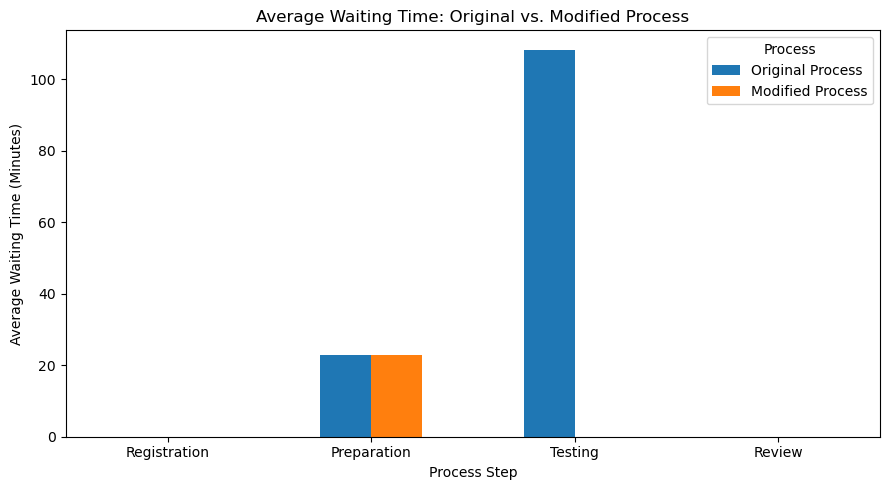

In [90]:
# Create comparison chart

comparison.set_index("Process Step").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Waiting Time: Original vs. Modified Process")
plt.xlabel("Process Step")
plt.ylabel("Average Waiting Time (Minutes)")
plt.xticks(rotation=0)
plt.legend(title="Process")
plt.tight_layout()
plt.show()

In [91]:
# Overall performance comparison

original_total = statistics.mean(total_times)
modified_total = statistics.mean(modified_total_times)

time_reduction = (
    (original_total - modified_total) / original_total
) * 100

throughput_increase = (
    (len(modified_total_times) - len(total_times)) / len(total_times)
) * 100

overall_comparison = pd.DataFrame({
    "Measure": [
        "Samples Completed",
        "Average Total Time in System (minutes)"
    ],
    "Original Process": [
        len(total_times),
        round(original_total, 2)
    ],
    "Modified Process": [
        len(modified_total_times),
        round(modified_total, 2)
    ]
})

display(overall_comparison)

print(f"Reduction in average total time: {time_reduction:.2f}%")
print(f"Increase in samples completed: {throughput_increase:.2f}%")

,Measure,Original Process,Modified Process
0,Samples Completed,30.0,57.00
1,Average Total Time in System (minutes),146.7,52.94


Reduction in average total time: 63.91%
Increase in samples completed: 90.00%


## 4. Comparison of Results

The simulation results show a substantial improvement after increasing the testing capacity from one analyzer to two analyzers.

In the original process, only 30 samples were completed during the eight-hour simulation. The average waiting time at the Testing/Analysis stage was 108.31 minutes, making it the primary bottleneck. The average total time that a completed sample spent in the system was 146.70 minutes.

After increasing the analyzer capacity from one to two, 57 samples were completed during the same simulation period. The average waiting time for testing decreased from 108.31 minutes to 0.00 minutes, while the average total time in the system decreased from 146.70 minutes to 52.94 minutes.

The modified process therefore reduced the average total time in the system by approximately 63.91% and increased the number of completed samples by 90%. These results indicate that increasing testing capacity significantly improved the performance of the laboratory process.

However, sample preparation still had an average waiting time of 22.98 minutes. This suggests that after resolving the testing bottleneck, sample preparation becomes the next area that could be considered for future process improvement.

## Conclusion

This simulation demonstrated how queue modeling can be used to identify and evaluate bottlenecks in a routine laboratory process. The original model showed that the Testing/Analysis stage created the greatest delay because one analyzer could not process samples as quickly as they arrived.

Increasing the number of analyzers from one to two eliminated the observed testing wait in this simulation run and substantially reduced the average amount of time completed samples spent in the system. It also increased the number of samples completed during the simulated eight-hour workday.

The comparison demonstrates that simulation can be useful for testing process changes before they are implemented in a real environment. It also shows that improving one bottleneck can reveal another constraint, as sample preparation remained the stage with the greatest average waiting time in the modified model.